# Task 2: Exploratory Data Analysis

This notebook performs exploratory analysis of the Milan mobile network traffic dataset.

The objectives are:

- Characterize traffic distribution across geographical areas
- Identify high-traffic regions
- Analyze temporal patterns
- Evaluate stationarity
- Perform seasonal decomposition
- Study autocorrelation
- Investigate spatial patterns
- Detect anomalies

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

plt.style.use("default")

In [2]:
df = pd.read_parquet(
    "/content/drive/MyDrive/mobile-dataset/milan_final.parquet"
)

print(df.shape)

df.head()

(89245318, 3)


,square_id,time_interval,internet
0,1,1383260400000,11.028366
1,1,1383261000000,11.127101
2,1,1383261600000,10.892771
3,1,1383262200000,8.622424
4,1,1383262800000,8.009928


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89245318 entries, 0 to 89245317
Data columns (total 3 columns):
 #   Column         Dtype  
---  ------         -----  
 0   square_id      int16  
 1   time_interval  int64  
 2   internet       float32
dtypes: float32(1), int16(1), int64(1)
memory usage: 1.2 GB


Probability Density Function

In [4]:
total_traffic = (
    df.groupby("square_id")
      ["internet"]
      .sum()
      .reset_index()
)

total_traffic.head()

,square_id,internet
0,1,92992.664062
1,2,93368.390625
2,3,93768.328125
3,4,91904.382812
4,5,83630.695312


In [5]:
total_traffic.shape

(10000, 2)

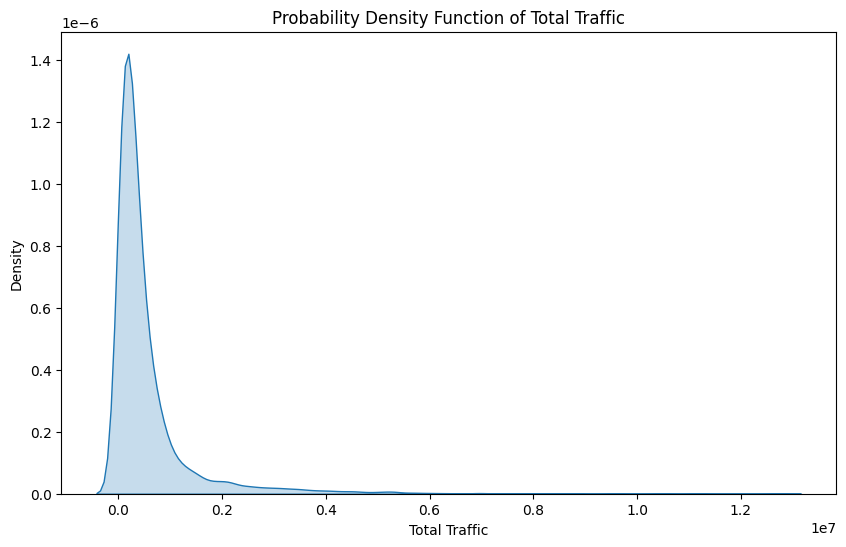

In [6]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    total_traffic["internet"],
    fill=True
)

plt.title(
    "Probability Density Function of Total Traffic"
)

plt.xlabel(
    "Total Traffic"
)

plt.ylabel(
    "Density"
)

plt.show()

Find Required Squares

In [7]:
# find highest traffic
top_square = (
    total_traffic
    .sort_values(
        "internet",
        ascending=False
    )
)

top_square.head()

,square_id,internet
5160,5161,12740060.0
5058,5059,11170854.0
5258,5259,10485780.0
5060,5061,9584334.0
5257,5258,8707440.0


In [8]:
# get id

highest_square = (
    top_square.iloc[0]["square_id"]
)

highest_square

np.float32(5161.0)

Extract Time Series

In [9]:
# convert timestamps
df["datetime"] = pd.to_datetime(
    df["time_interval"],
    unit="ms"
)

In [10]:
# create timestamps
square1 = df[
    df["square_id"] == highest_square
]

square2 = df[
    df["square_id"] == 4159
]

square3 = df[
    df["square_id"] == 4556
]

First Two Weeks Only

In [11]:
start_date = df["datetime"].min()

end_date = (
    start_date
    + pd.Timedelta(days=14)
)

square1_2w = square1[
    square1["datetime"] < end_date
]

square2_2w = square2[
    square2["datetime"] < end_date
]

square3_2w = square3[
    square3["datetime"] < end_date
]


Stationarity Analysis

In [12]:
# chosen highest traffic square
ts = (
    square1
    .sort_values("datetime")
    .set_index("datetime")
)["internet"]

Rolling mean

In [13]:
rolling_mean = ts.rolling(
    window=144
).mean()

rolling_std = ts.rolling(
    window=144
).std()

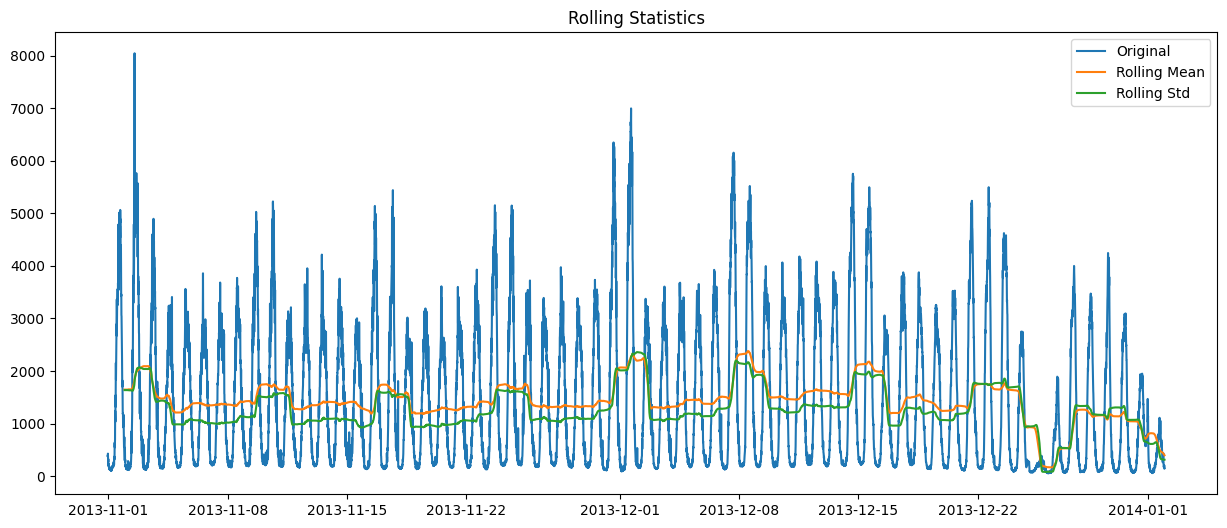

In [14]:
plt.figure(figsize=(15,6))

plt.plot(
    ts,
    label="Original"
)

plt.plot(
    rolling_mean,
    label="Rolling Mean"
)

plt.plot(
    rolling_std,
    label="Rolling Std"
)

plt.legend()

plt.title(
    "Rolling Statistics"
)

plt.show()

ADF Test

In [15]:
result = adfuller(
    ts.dropna()
)

print(
    "ADF Statistic:",
    result[0]
)

print(
    "p-value:",
    result[1]
)

ADF Statistic: -19.031899193303335
p-value: 0.0


Time Series Decomposition

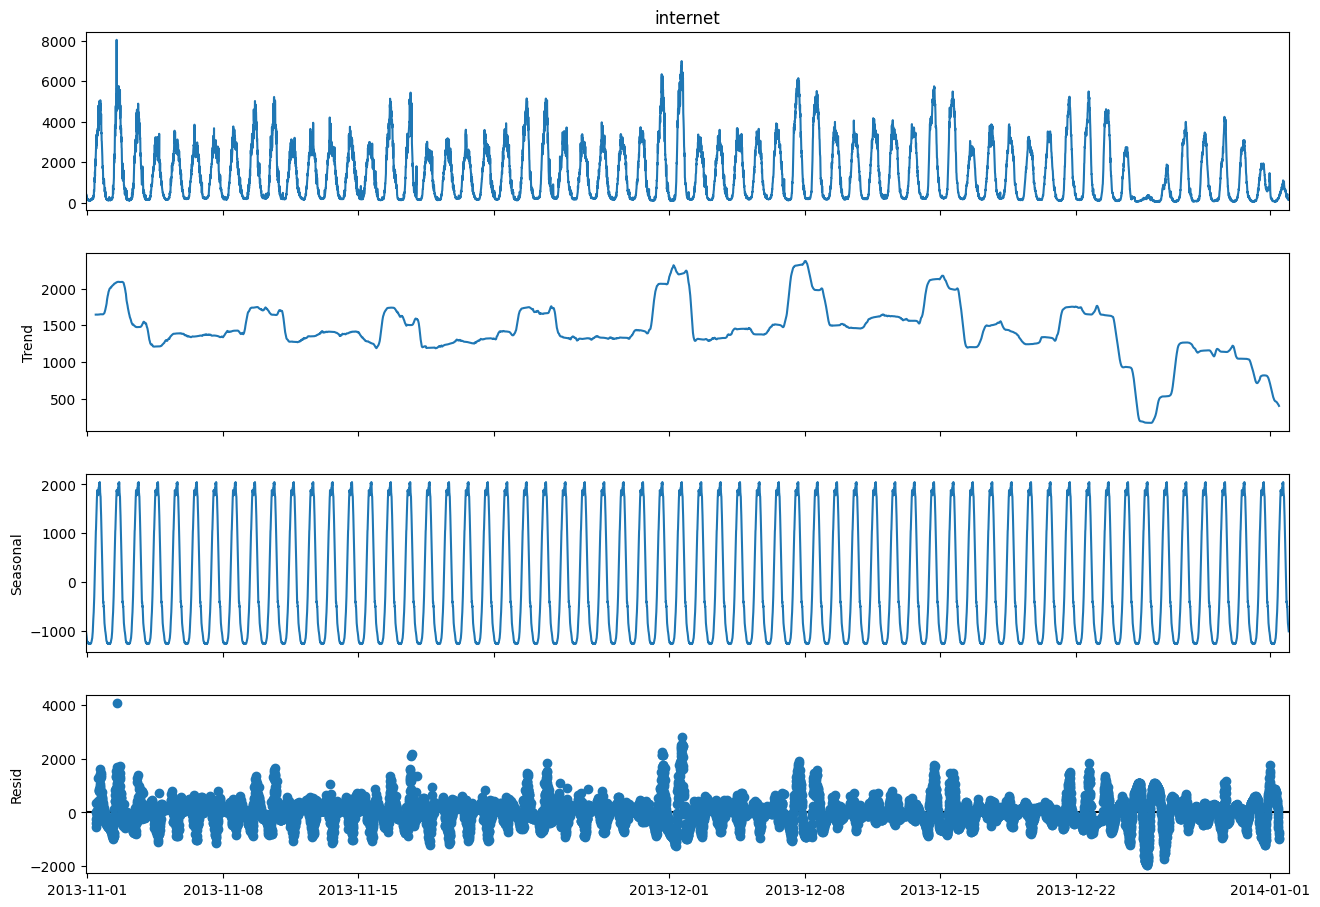

In [16]:
decomposition = seasonal_decompose(
    ts,
    model="additive",
    period=144
)

fig = decomposition.plot()

fig.set_size_inches(
    15,
    10
)

plt.show()

ACF and PACF

<Figure size 1200x600 with 0 Axes>

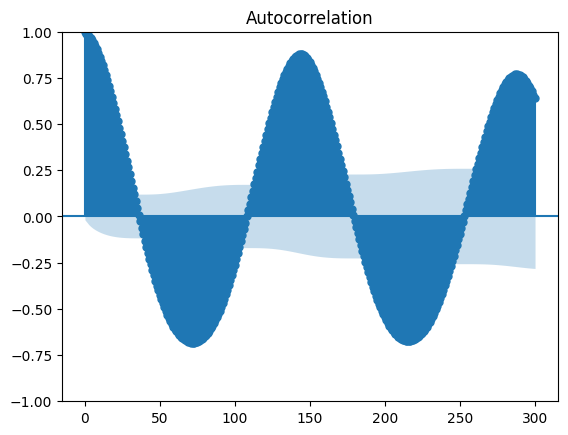

In [17]:
plt.figure(figsize=(12,6))

plot_acf(
    ts,
    lags=300
)

plt.show()

PACF

<Figure size 1200x600 with 0 Axes>

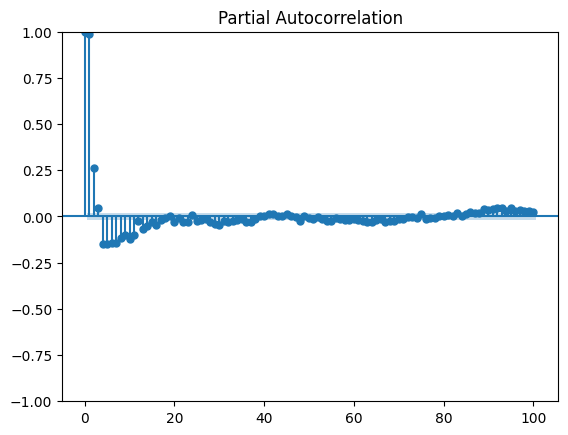

In [18]:
plt.figure(figsize=(12,6))

plot_pacf(
    ts,
    lags=100
)

plt.show()

Spatial Analysis (Heatmap)

In [19]:
heatmap_df = (
    df.groupby("square_id")
      ["internet"]
      .sum()
      .reset_index()
)

In [20]:
# total traffic per square

heatmap_df = (
    df.groupby("square_id")
      ["internet"]
      .sum()
      .reset_index()
)

# create coordinates

heatmap_df["row"] = (
    heatmap_df["square_id"] - 1
) // 100

heatmap_df["col"] = (
    heatmap_df["square_id"] - 1
) % 100

# create grid

grid = np.zeros(
    (100,100)
)

# fill grid
for _, r in heatmap_df.iterrows():

    grid[
        int(r["row"]),
        int(r["col"])
    ] = r["internet"]


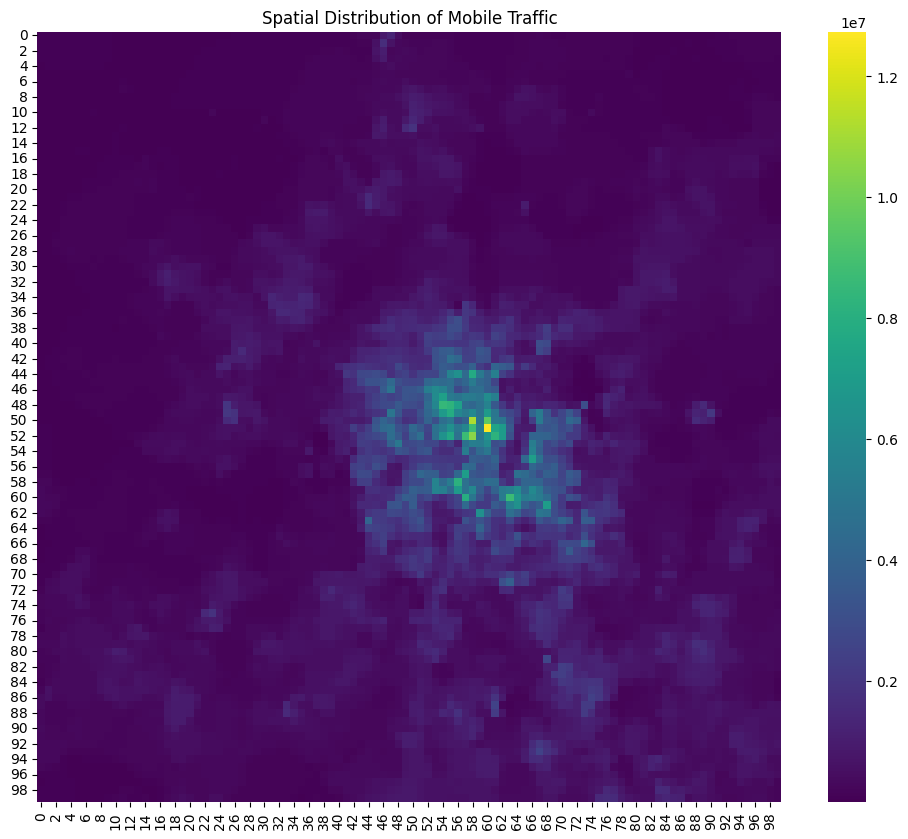

In [21]:
plt.figure(figsize=(12,10))

sns.heatmap(
    grid,
    cmap="viridis"
)

plt.title(
    "Spatial Distribution of Mobile Traffic"
)

plt.show()

Anomaly Detection

In [22]:
# compute z scores
from scipy.stats import zscore

anomaly_df = square1.copy()

anomaly_df["z"] = zscore(
    anomaly_df["internet"]
)

# define anomalies
anomalies = anomaly_df[
    np.abs(anomaly_df["z"]) > 3
]

print(
    len(anomalies)
)

51


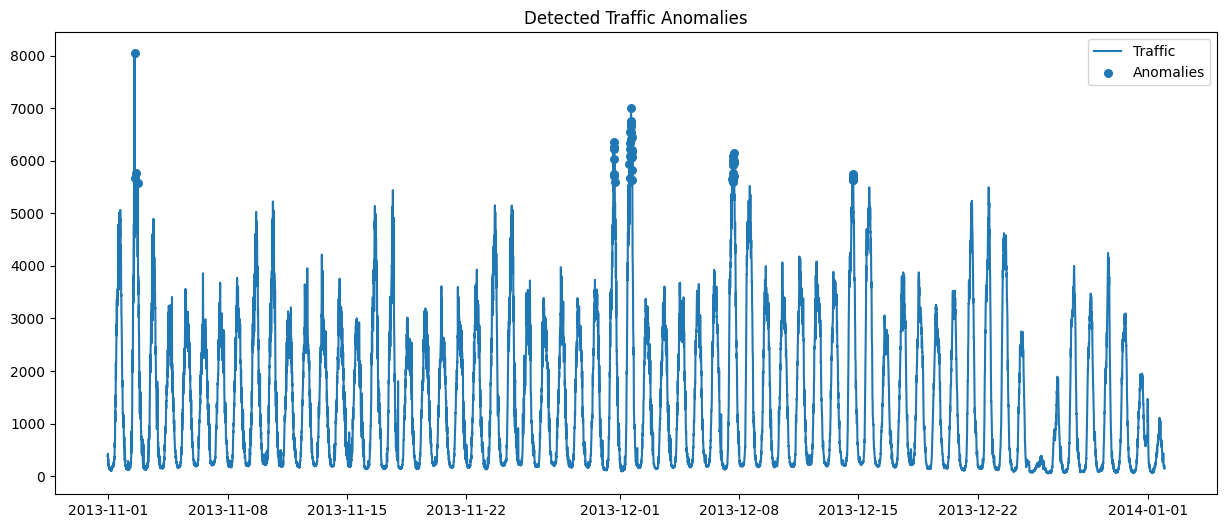

In [23]:
plt.figure(figsize=(15,6))

plt.plot(
    anomaly_df["datetime"],
    anomaly_df["internet"],
    label="Traffic"
)

plt.scatter(
    anomalies["datetime"],
    anomalies["internet"],
    s=30,
    label="Anomalies"
)

plt.legend()

plt.title(
    "Detected Traffic Anomalies"
)

plt.show()

Daily Traffic Pattern

In [24]:
# extract hour

df["hour"] = df["datetime"].dt.hour

# compute average
hourly = (
    df.groupby("hour")
      ["internet"]
      .mean()
)


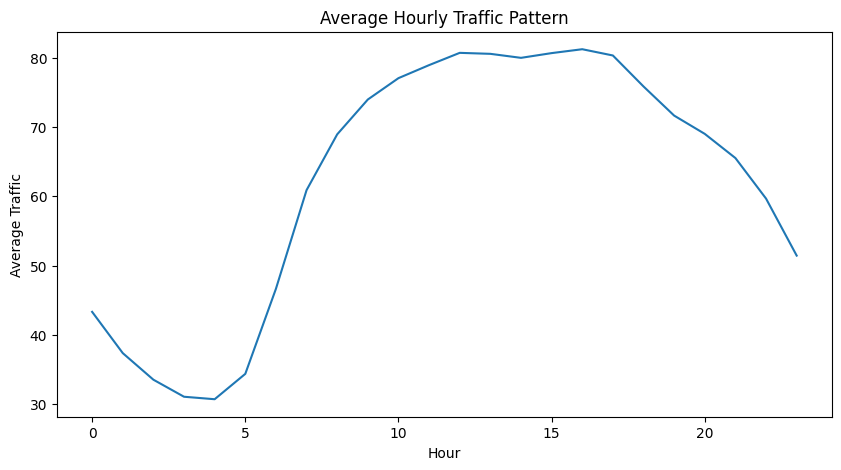

In [25]:
plt.figure(figsize=(10,5))

hourly.plot()

plt.title(
    "Average Hourly Traffic Pattern"
)

plt.xlabel("Hour")

plt.ylabel("Average Traffic")

plt.show()